In [130]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [60]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

In [131]:
with open('model/keypoint_classifier/keypoint_classifier_label.csv', 'r') as f:
    labels = f.readlines()

print("Labels:")
for label in labels:
    print(label.strip()) 

Labels:
ï»¿washroom
i love u
yes
call me
hi
good job
dislike
good luck
rock
you
ok
looser
bang bang
peace
hate u
stare
i really love u
thank u
i am hungry
i need water
i am fine
give me FOOD
vulcan salute
stop
some
help
go to hell
cut ur nails
open relationship
tea time
check pleace
SHOCKER
hurts a lot
i want to talk
stay strong
up
down
smile
please
i
anything


In [128]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  
cord = pd.read_csv(dataset)
print("First 5 coordinates:")
print(cord.iloc[:, 1:11].head().to_string(index=False))

First 5 coordinates:
 0.0  0.0.1  -0.2361111111111111  -0.19907407407407407  -0.30092592592592593  -0.5277777777777778  -0.1527777777777778  -0.7685185185185185  0.018518518518518517  -0.9351851851851852
 0.0    0.0            -0.261261             -0.162162             -0.351351            -0.495495            -0.184685            -0.761261             -0.022523            -0.941441
 0.0    0.0            -0.255605             -0.179372             -0.345291            -0.506726            -0.174888            -0.762332              0.000000            -0.923767
 0.0    0.0            -0.245536             -0.196429             -0.316964            -0.517857            -0.156250            -0.767857              0.000000            -0.937500
 0.0    0.0            -0.251101             -0.185022             -0.330396            -0.524229            -0.171806            -0.779736             -0.013216            -0.942731
 0.0    0.0            -0.243363             -0.199115          

# Set number of classes

In [61]:
NUM_CLASSES = 41

# Dataset reading

In [62]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [63]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [65]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [66]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 20)                860       
                                                                 
 batch_normalization_10 (Ba  (None, 20)                80        
 tchNormalization)                                               
                                                                 
 dropout_10 (Dropout)        (None, 20)                0         
                                                                 
 dense_16 (Dense)            (None, 10)                210       
                                                                 
 batch_normalization_11 (Ba  (None, 10)                40        
 tchNormalization)                                               
                                                                 
 dropout_11 (Dropout)        (None, 10)               

In [67]:

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)

es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [68]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [69]:
history=model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
88/95 [==========================>...] - ETA: 0s - loss: 3.2552 - accuracy: 0.1506
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 4s 13ms/step - loss: 3.2246 - accuracy: 0.1617 - val_loss: 3.4105 - val_accuracy: 0.2268
Epoch 2/1000
87/95 [==========================>...] - ETA: 0s - loss: 2.5080 - accuracy: 0.4075
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 2.4825 - accuracy: 0.4155 - val_loss: 2.9577 - val_accuracy: 0.4383
Epoch 3/1000
92/95 [============================>.] - ETA: 0s - loss: 1.9603 - accuracy: 0.5757
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 1.9533 - accuracy: 0.5777 - val_loss: 2.3660 - val_accuracy: 0.6997
Epoch 4/1000
91/95 [===========================>..] - ETA: 0s - loss: 1.5283 - accuracy: 0.67

95/95 [==============================] - ETA: 0s - loss: 0.2167 - accuracy: 0.9297
Epoch 28: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 0.2167 - accuracy: 0.9297 - val_loss: 0.0191 - val_accuracy: 0.9985
Epoch 29/1000
89/95 [===========================>..] - ETA: 0s - loss: 0.2141 - accuracy: 0.9333
Epoch 29: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 8ms/step - loss: 0.2117 - accuracy: 0.9338 - val_loss: 0.0183 - val_accuracy: 0.9983
Epoch 30/1000
95/95 [==============================] - ETA: 0s - loss: 0.2095 - accuracy: 0.9303
Epoch 30: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 0.2095 - accuracy: 0.9303 - val_loss: 0.0216 - val_accuracy: 0.9980
Epoch 31/1000
86/95 [==========================>...] - ETA: 0s - loss: 0.2044 - accuracy: 0.9346
Epoch

Epoch 55/1000
89/95 [===========================>..] - ETA: 0s - loss: 0.1310 - accuracy: 0.9558
Epoch 55: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 8ms/step - loss: 0.1318 - accuracy: 0.9555 - val_loss: 0.0099 - val_accuracy: 0.9983
Epoch 56/1000
92/95 [============================>.] - ETA: 0s - loss: 0.1392 - accuracy: 0.9534
Epoch 56: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 8ms/step - loss: 0.1384 - accuracy: 0.9536 - val_loss: 0.0089 - val_accuracy: 0.9983
Epoch 57/1000
91/95 [===========================>..] - ETA: 0s - loss: 0.1326 - accuracy: 0.9578
Epoch 57: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 8ms/step - loss: 0.1324 - accuracy: 0.9581 - val_loss: 0.0102 - val_accuracy: 0.9985
Epoch 58/1000
89/95 [===========================>..] - ETA: 0s - loss: 0.1401 - accuracy

Epoch 82/1000
94/95 [============================>.] - ETA: 0s - loss: 0.1133 - accuracy: 0.9604
Epoch 82: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 0.1128 - accuracy: 0.9604 - val_loss: 0.0088 - val_accuracy: 0.9990
Epoch 83/1000
91/95 [===========================>..] - ETA: 0s - loss: 0.1075 - accuracy: 0.9639
Epoch 83: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 0.1077 - accuracy: 0.9641 - val_loss: 0.0116 - val_accuracy: 0.9985
Epoch 84/1000
95/95 [==============================] - ETA: 0s - loss: 0.1113 - accuracy: 0.9612
Epoch 84: saving model to model/keypoint_classifier\keypoint_classifier.keras
95/95 [==============================] - 1s 9ms/step - loss: 0.1113 - accuracy: 0.9612 - val_loss: 0.0084 - val_accuracy: 0.9983
Epoch 85/1000
89/95 [===========================>..] - ETA: 0s - loss: 0.1062 - accuracy

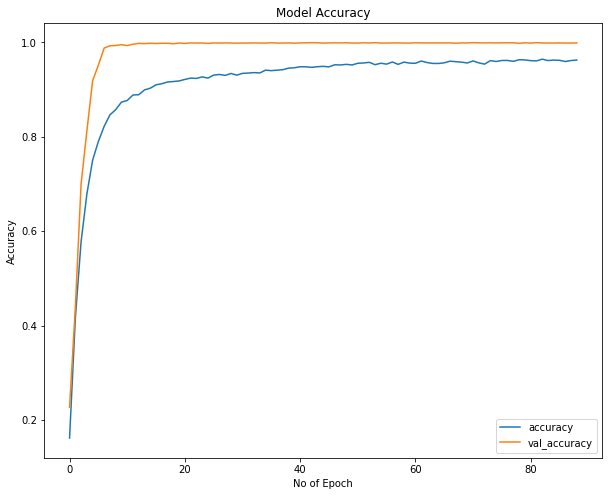

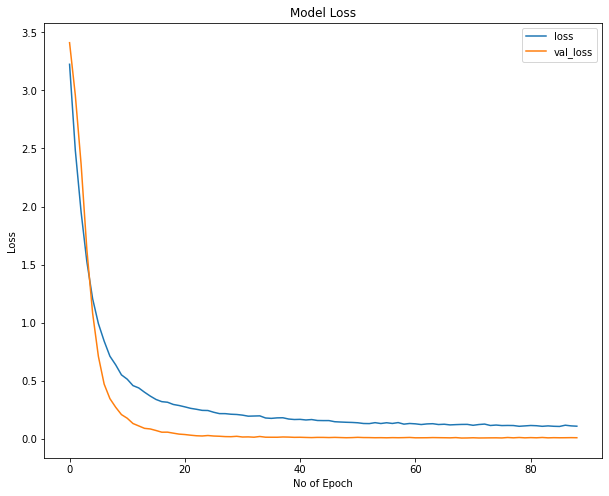

In [112]:
# Plotting accuracy and validation accuracy
plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('No of Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting loss and validation loss
plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('No of Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [71]:
#Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

32/32 [==============================] - 0s 4ms/step - loss: 0.0094 - accuracy: 0.9985


In [72]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [73]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 321ms/step
[1.5446503e-14 2.8059808e-06 2.0994586e-12 1.2055347e-07 1.0389766e-08
 3.1864065e-14 2.7766985e-08 9.7535554e-18 3.6323049e-11 4.7907872e-10
 9.0760406e-16 9.9999595e-01 3.3754036e-14 1.4438468e-08 3.3170572e-10
 3.5642433e-08 4.4630558e-12 1.7781887e-12 8.1545579e-08 1.0908569e-11
 2.5960068e-17 1.7417970e-07 3.8463191e-18 2.8046516e-13 9.6191393e-09
 1.6495115e-10 3.9271481e-12 2.1317255e-10 2.7027729e-14 3.6500831e-15
 9.0562127e-11 8.3764500e-13 5.6077023e-09 2.2658353e-11 2.3387953e-11
 5.5908606e-07 1.6576054e-07 1.4652587e-12 4.8803518e-13 2.0324187e-11
 2.3342318e-11]
11


In [74]:
#Confusion matrix

In [75]:
# pip install seaborn


Note: you may need to restart the kernel to use updated packages.


127/127 [==============================] - 0s 2ms/step


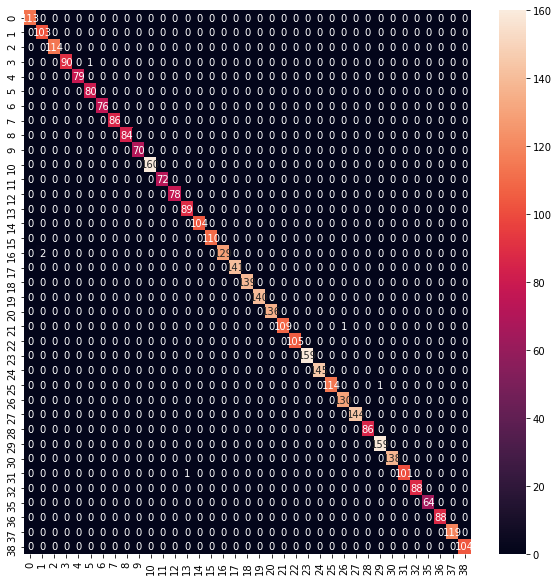

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       0.98      1.00      0.99       103
           2       1.00      1.00      1.00       114
           3       1.00      0.99      0.99        91
           4       1.00      1.00      1.00        79
           5       0.99      1.00      0.99        80
           6       1.00      1.00      1.00        76
           7       1.00      1.00      1.00        86
           8       1.00      1.00      1.00        84
           9       1.00      1.00      1.00        70
          10       1.00      1.00      1.00       160
          11       1.00      1.00      1.00        72
          12       1.00      1.00      1.00        78
          13       0.99      1.00      0.99        89
          14       1.00      1.00      1.00       104
          15       1.00      1.00      1.00       110
          16       1.00      0.98      0.99       131
     

None

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(10,10))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

output = print_confusion_matrix(y_test, y_pred)

display(output)


# Convert to model for Tensorflow-Lite

In [114]:
# Save as a model dedicated to inference
#model.save(model_save_path, include_optimizer=False)
model.save(model_save_path)


In [115]:
# Transform model (quantization)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\SRIVAT~1\AppData\Local\Temp\tmp1fj86439\assets


INFO:tensorflow:Assets written to: C:\Users\SRIVAT~1\AppData\Local\Temp\tmp1fj86439\assets


8788

In [116]:
#Inference test

In [117]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [118]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [119]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [120]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

Wall time: 0 ns


In [121]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.54465013e-14 2.80597556e-06 2.09946253e-12 1.20553565e-07
 1.03898250e-08 3.18640649e-14 2.77671433e-08 9.75359183e-18
 3.63230453e-11 4.79078666e-10 9.07611050e-16 9.99995947e-01
 3.37540969e-14 1.44384682e-08 3.31706357e-10 3.56423620e-08
 4.46306403e-12 1.77819207e-12 8.15457355e-08 1.09086325e-11
 2.59601669e-17 1.74180201e-07 3.84633319e-18 2.80466243e-13
 9.61912150e-09 1.64951441e-10 3.92717065e-12 2.13172535e-10
 2.70278828e-14 3.65009706e-15 9.05621342e-11 8.37648147e-13
 5.60769209e-09 2.26583960e-11 2.33879964e-11 5.59086004e-07
 1.65760852e-07 1.46525294e-12 4.88036098e-13 2.03242249e-11
 2.33423610e-11]
11
